In [1]:
print("hello")

hello


In [2]:
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
import os
from pathlib import Path
from PIL import Image
import psutil
from tqdm import tqdm

import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np

# DATA HANDLING

* **Manage satellite image datasets using Keras and Python libraries**

* **Compare memory-based and generator-based data loading strategies in terms of performance, memory efficiency, and implementation complexity**

* **Build a simple, memory-efficient image pipeline by loading and visualizing geospatial image data sequentially**

* **Assess the trade-offs between loading entire image datasets into memory versus accessing image paths on demand**


In [4]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

class_0_non_agri is the non-agricultural land class, as defined earlier, and it represents images with non-cultivable land.
class_1_agri, on the other hand, is the agricultural land class, and it represents the images with cultivable land.

**os.scandir** to build an iterator

In [5]:
non_agri = os.scandir(dir_non_agri)

for i in range(3):
    print(next(non_agri))

<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg'>


In [6]:
file_name = next(non_agri)
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg'

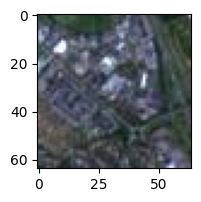

In [7]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data.shape
plt.figure(figsize=(4, 2))
plt.imshow(image_data)

<b>Strategy 1 — Memory-Based Loading</b><br>
Load every single image from disk into RAM at once, store them all as a big NumPy array.

In [8]:
def get_ram_usage_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)  

In [9]:
%%time

before_ram = get_ram_usage_mb()

non_agri_images = []
non_agri = os.scandir(dir_non_agri)

for file_name in non_agri:
    if os.path.isfile(file_name):
        image_name = str(file_name).split("'")[1]
        image_data = plt.imread(os.path.join(dir_non_agri,image_name))
        non_agri_images.append(image_data)

non_agri_images = np.array(non_agri_images)        

after_ram = get_ram_usage_mb()
print(f"RAM used: {after_ram - before_ram:.2f} MB")

RAM used: 37.94 MB
CPU times: total: 2.81 s
Wall time: 2.95 s


In [10]:
agri_images = []

for entry in os.scandir(dir_agri):
    if entry.is_file():
        image_data = plt.imread(entry.path)
        agri_images.append(image_data)

agri_images = np.array(agri_images)

CPU times: total: 2.09 s
Wall time: 2.28 s


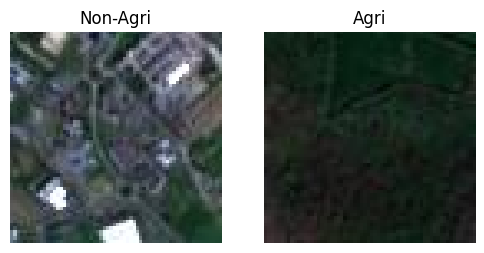

In [11]:
plt.figure(figsize=(6, 3))

# Left image (non-agri)
plt.subplot(1, 2, 1)
plt.imshow(non_agri_images[1])
plt.title("Non-Agri")
plt.axis('off')

# Right image (agri)
plt.subplot(1, 2, 2)
plt.imshow(agri_images[1])
plt.title("Agri")
plt.axis('off')

plt.show()

<b>Strategy 2 — Generator/Path-Based </b><br>
Store only the file paths (strings) in memory. Open each image only when you actually need it — one at a time or one batch at a time.

In [26]:
%%time

before_ram = get_ram_usage_mb()

non_agri_images = os.listdir(dir_non_agri) #listdir gives names only
non_agri_images.sort()
non_agri_images_paths = [os.path.join(dir_non_agri,image) for image in non_agri_images]

after_ram = get_ram_usage_mb()

print(f"RAM used: {after_ram - before_ram:.2f} MB")

RAM used: 0.54 MB
CPU times: total: 31.2 ms
Wall time: 29.7 ms


Looking at the results of psutil and %%time , Path based generator will be better in terms of memory required

In [27]:
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [28]:
non_agri_images_paths[:5]

['..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [29]:
len(non_agri_images_paths)

3000

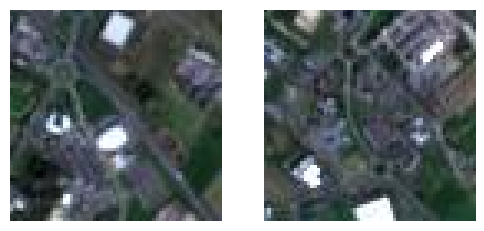

In [30]:
plt.figure(figsize=(6, 3))

for i in range(2):
    img = Image.open(non_agri_images_paths[i])

    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [31]:
agri_images = os.listdir(dir_agri)
agri_images.sort()
agri_images_paths = [os.path.join(dir_agri,image) for image in agri_images]
len(agri_images_paths)

3000

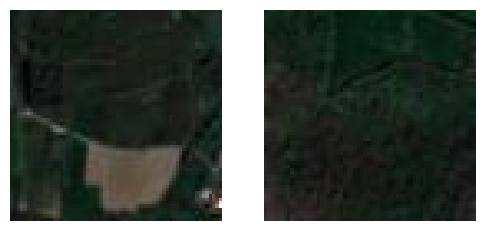

In [32]:
plt.figure(figsize=(6,3))

for i in range(2):
    img = Image.open(agri_images_paths[i])
    plt.subplot(1,2,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [33]:
(PROJECT_ROOT, RAW_DIR, dir_agri, dir_non_agri)

('..',
 '..\\data\\raw\\images_dataSAT',
 '..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

### Pre - Proccessing
Only deterministic preprocessing is done before split; no statistical normalization is applied
- Resize, format conversion (okay)
- Standardization, PCA, Tokenization leaks data 

In [60]:
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

processed_agri = os.path.join(PROCESSED_DIR, "class_1_agri")
processed_non_agri = os.path.join(PROCESSED_DIR, "class_0_non_agri")

img_size = (64, 64)

for path in tqdm(agri_images_paths, desc="Processing Agri"): ## tqdm just for process bar
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize(img_size)
        
        save_path = os.path.join(processed_agri, os.path.basename(path))
        img.save(save_path)
    except Exception as e:
        print("Skipped:", path)
        print("Error:", e)

for path in tqdm(non_agri_images_paths, desc="Processing Non-Agri"):
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize(img_size)
        
        save_path = os.path.join(processed_non_agri, os.path.basename(path))
        img.save(save_path)
    except Exception as e:
        print("Skipped:", path)
        print("Error:", e)

print("Preprocessing Done")

Processing Non-Agri: 100%|████████████████████████████████████████████████████████| 3000/3000 [00:06<00:00, 468.86it/s]

Preprocessing Done


### Splits

In [61]:
(processed_agri,os.listdir(processed_agri)[0])

('..\\data\\processed\\class_1_agri',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg')

In [62]:
filepaths = (
    [os.path.join(processed_agri, file_name) for file_name in os.listdir(processed_agri)] +
    [os.path.join(processed_non_agri, file_name) for file_name in os.listdir(processed_non_agri)]
)

In [63]:
labels = (
    [1]*len(os.listdir(processed_agri)) +
    [0]*len(os.listdir(processed_non_agri))
)

df = pd.DataFrame({
    "filepath": filepaths,
    "label": labels
})

In [64]:
train, temp = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val, test = train_test_split(temp, test_size=0.5, stratify=temp["label"], random_state=42)

In [65]:
os.makedirs("../data/splits", exist_ok=True)

train.to_csv("../data/splits/train.csv", index=False)
val.to_csv("../data/splits/val.csv", index=False)
test.to_csv("../data/splits/test.csv", index=False)

print("Splits Saved")

Splits Saved


### Data Loading and Augmentation Using Keras

* **Build and test a custom data generator in Keras for efficient, on-the-fly loading, and preprocessing of image datasets.**
* **Use Keras’s `image_dataset_from_directory` utility to load and preprocess datasets with optimized performance using the `tf.data` API.**
* **Apply image augmentation and performance optimizations such as `.map()`, `.cache()`, and `.prefetch()` to build high-throughput data pipelines.**
* **Compare custom and built-in Keras data loaders in terms of code complexity, flexibility, and runtime efficiency.**


In [66]:
def custom_data_generator(image_paths, labels, batch_size):
    num_samples = len(image_paths)

    while True:
        # shuffle data at the beginning of each epoch
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        # images and labels stay aligned after shuffle
        shuffled_paths = np.array(image_paths)[indices]
        shuffled_labels = np.array(labels)[indices]

        # Generate batch data
        for offset in range(0, num_samples, batch_size):
            batch_paths = shuffled_paths[offset:offset+batch_size]
            batch_labels = shuffled_labels[offset:offset+batch_size]
            
            # Load and preprocess images from the batch
            batch_images = []
            for path in batch_paths:
                img = tf.keras.utils.load_img(path)
                img_array = tf.keras.utils.img_to_array(img)
                batch_images.append(img_array)
            
            # Normalize and yield the batch data
            yield np.array(batch_images) / 255.0, np.array(batch_labels)

All image paths (on disk)
        ->
Shuffle
        ->
Pick 1 batch (e.g., 32)
        ->
Load only those images
        ->
Normalize
        ->
Give to model (yield)
        ->
Repeat forever

In [67]:
temp = list(zip(filepaths, labels))
np.random.shuffle(temp)
filepaths, labels = zip(*temp)

for path, label in zip(filepaths[:3], labels[:3]):
    print(path, label)

..\data\processed\class_0_non_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_0677.jpg 0
..\data\processed\class_1_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_2848.jpg 1
..\data\processed\class_1_agri\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_12521.jpg 1


In [68]:
batch_size = 8
data_generator = custom_data_generator(
    image_paths=filepaths,
    labels=labels,
    batch_size=batch_size
)

In [69]:
print(len(filepaths), len(labels))

6000 6000


In [70]:
images, batch_labels = next(data_generator)
# Print batch data statistics
print(f"Images batch shape: {images.shape}")
print(f"Labels batch shape: {batch_labels.shape}")

Images batch shape: (8, 64, 64, 3)
Labels batch shape: (8,)


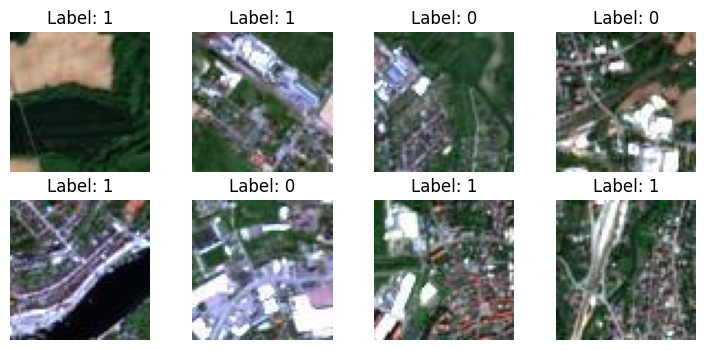

In [46]:
# Display the images in the batch
plt.figure(figsize=(9, 4))
for i in range(batch_size):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis("off")

## Keras' built-in utility

In [47]:
batch_size = 8

In [53]:
# Create a training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR,
    labels='inferred',          # Labels are generated from directory structure
    label_mode='int',           # Labels are encoded as integers (0, 1, ...)
    validation_split=0.2,       # 20% of images for validation
    subset='training',          
    seed=1337,                  # Shuffle seed
    batch_size=batch_size
)

Found 6000 files belonging to 2 classes.
Using 4800 files for training.


In [54]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    batch_size=batch_size
)

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


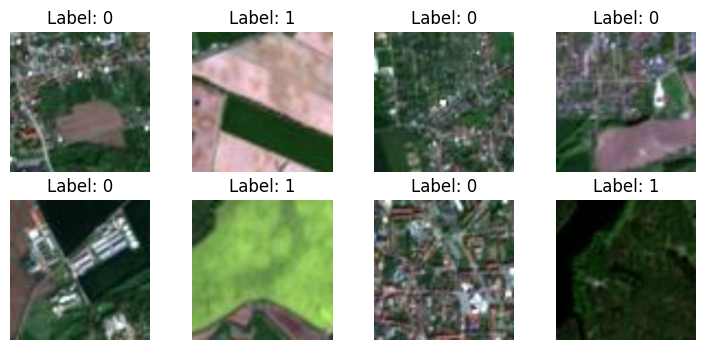

In [56]:
plt.figure(figsize=(9, 4))
for images, labels in train_ds.take(1):  # Take one batch
    for i in range(batch_size):
        ax = plt.subplot(2, 4, i + 1)
        # Images are loaded as float32, so we convert to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {int(labels[i])}")
        plt.axis("off")

## Data Augmentation

In [57]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

In [58]:
# Apply augmentation to the training dataset using map
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset is now configured for high performance!")

Dataset is now configured for high performance!
